### Код для локального сервера

In [ ]:
import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import OrdinalEncoder
import torch
from torch import nn
import torch.functional as F
from torch.utils.data import DataLoader, Subset, random_split

from torchvision.transforms import InterpolationMode
from torchvision import models
from torchvision.datasets import VisionDataset
from torchvision.transforms import ToTensor, Resize, Normalize, Compose, RandomResizedCrop, ColorJitter, RandomHorizontalFlip, RandomPerspective, RandomRotation, InterpolationMode, RandomApply, GaussianBlur

import random
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

from PIL import Image

from tqdm import tqdm
import re

import os
import requests

import warnings
warnings.filterwarnings("ignore")

In [ ]:
root_dir = "data"
img_dir = "images"
csv_path = "good_atomic_no_noise_less_noresident.csv"

In [ ]:
def get_idx_row_from_image(img_name, data):
    (id, img_num) = img_name.split(".")[0].split("_")
    id = int(id)
    img_num = int(img_num)
    series = data[(data["ID"] == id) & (data["img_num"] == img_num)]
    idx = series.index[0]
    row = series.iloc[0]

    return (idx, row)

In [ ]:
class Attr(VisionDataset):
    def __init__(self, root_dir, img_dir, csv_path, transform=None):
        self.root_dir = root_dir
        self.img_dir = img_dir
        self.csv_path = csv_path

        super().__init__(self.root_dir, transform=transform)

        self.transform = transform

        self.image_paths = []
        self.labels = []
        self.orig_indices = []

        self._build_dataset()

    def _build_dataset(self):
        data = pd.read_csv(os.path.join(self.root_dir, self.csv_path))
        for img_name in os.listdir(os.path.join(self.root_dir, self.img_dir)):
            #idx = int(img_name.split('.')[0]) // old

            try:
                idx, row = get_idx_row_from_image(img_name, data)
            except:
                continue


            self.labels.append(row.attr_ind)
            self.orig_indices.append(idx)

            img_path = os.path.join(self.root_dir, self.img_dir, img_name)
            self.image_paths.append(img_path)

        print(f"Dataset loaded: {len(self.image_paths)} images")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
default_transform = Compose(
    [Resize((384, 384)), ToTensor(), Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]
)

ds = Attr(transform=default_transform, root_dir=root_dir, img_dir=img_dir, csv_path=csv_path)

Dataset loaded: 13931 images


In [ ]:
train_test_split = 0.9
train_val_split = 1
train_size = int(train_test_split * len(ds))
test_size = len(ds) - train_size
val_size = train_size - int(train_size * train_val_split)
train_size = int(train_size * train_val_split)

generator = torch.Generator().manual_seed(42)
train_ds, val_ds, test_ds = random_split(ds, [train_size, val_size, test_size], generator=generator)

#### Аугментации

In [ ]:
train_transform = Compose([
    RandomResizedCrop(
        size=(384, 384),
        scale=(0.7, 1.0),
        ratio=(0.9, 1.1)
    ),
    RandomHorizontalFlip(p=0.5),

    ColorJitter(
        brightness=0.2,
        contrast=0.3,
        saturation=0.15,
        hue=0.05
    ),

    RandomApply([
        GaussianBlur(kernel_size=3, sigma=(0.1, 0.7))
    ], p=0.2),

    RandomApply([
        RandomRotation(
            degrees=7,
            interpolation=InterpolationMode.BILINEAR
        )
    ], p=0.3),

    RandomApply([
        RandomPerspective(
            distortion_scale=0.15,
            p=1.0
        )
    ], p=0.2),

    ToTensor(),

    Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

default_transform = Compose([
    Resize((384, 384)),
    ToTensor(),
    Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

train_ds.transform = train_transform

#### Модельки

In [ ]:
def train_model(model, train_loader, val_loader, epochs, lr, do_val, weights=None):
    criterion = nn.CrossEntropyLoss()
    if weights is not None:
        criterion.weight = weights

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01, betas=(0.9, 0.999))

    history = {"train_loss": []}
    if do_val:
        history["val_acc"] = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        print("Training:")
        for x, y in tqdm(train_loader):
            x = x.to(device)
            y = y.to(device).long()

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_loss = train_loss / len(train_loader)
        history["train_loss"].append(avg_loss)

        print(f"Epoch {epoch+1}/{epochs}:")
        print(f"  Train loss: {avg_loss:.4f}")

        if not do_val:
            continue

        model.eval()
        all_probs = []
        all_preds = []
        all_y = []

        print("Validation:")
        with torch.no_grad():
            for x, y in tqdm(val_loader):
                x = x.to(device)
                y = y.to(device).long()

                out = model(x)
                probs = torch.softmax(out, dim=1)
                preds = torch.argmax(probs, dim=1)

                all_probs.append(probs.cpu())
                all_preds.append(preds.cpu())
                all_y.append(y.cpu())

        all_probs = torch.cat(all_probs).numpy()
        all_preds = torch.cat(all_preds).numpy()
        all_y = torch.cat(all_y).numpy()

        val_acc = accuracy_score(all_y, all_preds)

        print(f"  Val acc: {val_acc:.4f}")

        history["val_acc"].append(val_acc)

    return history

In [ ]:
model = models.convnext_small(weights="ConvNeXt_Small_Weights.DEFAULT")

for p in model.parameters():
    p.requires_grad = False

model.classifier[2] = nn.Linear(model.classifier[2].in_features, 9, bias=True)

#### Треним

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
device

'cuda'

In [ ]:
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

hist = train_model(model, train_loader=train_loader, val_loader=val_loader, epochs=3, lr=0.001, do_val=True)

Training:


100%|██████████| 196/196 [03:29<00:00,  1.07s/it]


Epoch 1/3:
  Train loss: 1.2373
Validation:


100%|██████████| 22/22 [00:23<00:00,  1.08s/it]


  Val acc: 0.5775
  Val micro f1: 0.5775
  Val macro f1: 0.4590
  Val AUC (OvR, macro): 0.8905
Training:


...

  Val acc: 0.6119
  Val micro f1: 0.6119
  Val macro f1: 0.5138
  Val AUC (OvR, macro): 0.9087
Training:


100%|██████████| 196/196 [03:17<00:00,  1.01s/it]


Epoch 3/3:
  Train loss: 0.9891
Validation:


100%|██████████| 22/22 [00:21<00:00,  1.02it/s]

  Val acc: 0.6098
  Val micro f1: 0.6098
  Val macro f1: 0.5508
  Val AUC (OvR, macro): 0.9154


In [ ]:
model.modules

<bound method Module.modules of ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
  

#### Тюним

батч поменьше

In [ ]:
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

for p in model.features[7].parameters():
    p.requires_grad = True
for p in model.features[6].parameters():
    p.requires_grad = True
hist = train_model(model, train_loader=train_loader, val_loader=val_loader, epochs=1, lr=0.0007, do_val=True)

Training:


100%|██████████| 392/392 [03:34<00:00,  1.82it/s]


Epoch 1/1:
  Train loss: 1.0343
Validation:


100%|██████████| 22/22 [00:21<00:00,  1.04it/s]

  Val acc: 0.6162
  Val micro f1: 0.6162
  Val macro f1: 0.5777
  Val AUC (OvR, macro): 0.9281


In [ ]:
for p in model.features[5][20:].parameters():
    p.requires_grad = True
hist = train_model(model, train_loader=train_loader, val_loader=val_loader, epochs=1, lr=0.0005, do_val=True)

Training:


100%|██████████| 392/392 [03:59<00:00,  1.64it/s]


Epoch 1/1:
  Train loss: 0.8966
Validation:


100%|██████████| 22/22 [00:22<00:00,  1.03s/it]

  Val acc: 0.6736
  Val micro f1: 0.6736
  Val macro f1: 0.5755
  Val AUC (OvR, macro): 0.9433


In [ ]:
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)

for p in model.features[5][10:].parameters():
    p.requires_grad = True
hist = train_model(model, train_loader=train_loader, val_loader=val_loader, epochs=1, lr=0.0001, do_val=True)

Training:


100%|██████████| 784/784 [05:24<00:00,  2.42it/s]


Epoch 1/1:
  Train loss: 0.6847
Validation:


100%|██████████| 22/22 [00:23<00:00,  1.08s/it]

  Val acc: 0.6894
  Val micro f1: 0.6894
  Val macro f1: 0.5861
  Val AUC (OvR, macro): 0.9529


In [ ]:
for p in model.features[5].parameters():
    p.requires_grad = True

hist = train_model(model, train_loader=train_loader, val_loader=val_loader, epochs=1, lr=0.00005, do_val=True)

Training:


100%|██████████| 784/784 [06:33<00:00,  1.99it/s]


Epoch 1/1:
  Train loss: 0.4320
Validation:


100%|██████████| 22/22 [00:24<00:00,  1.13s/it]

  Val acc: 0.7009
  Val micro f1: 0.7009
  Val macro f1: 0.6940
  Val AUC (OvR, macro): 0.9544


In [ ]:
for p in model.parameters():
    p.requires_grad = True

hist = train_model(model, train_loader=train_loader, val_loader=val_loader, epochs=1, lr=0.00001, do_val=True)

Training:


100%|██████████| 784/784 [07:41<00:00,  1.70it/s]


Epoch 1/2:
  Train loss: 0.1470
Validation:


100%|██████████| 22/22 [00:22<00:00,  1.04s/it]


  Val acc: 0.7303
  Val micro f1: 0.7303
  Val macro f1: 0.7061
  Val AUC (OvR, macro): 0.9565
Training:


 40%|███▉      | 312/784 [03:05<04:40,  1.68it/s]


KeyboardInterrupt: 

In [ ]:
k = 0
for p in model.parameters():
    if p.requires_grad:
        k += 1
k

4

#### Тестим

100%|██████████| 44/44 [00:24<00:00,  1.78it/s]


accuracy on class 0: 0.8284
accuracy on class 1: 0.6667
accuracy on class 2: 0.8500
accuracy on class 3: 0.6000
accuracy on class 4: 0.8305
accuracy on class 5: 0.5394
accuracy on class 6: 0.6518
accuracy on class 7: 0.6842
accuracy on class 8: 0.5333

  Test accuracy: 0.7174
  Test f1 micro: 0.7174
  Test f1 macro: 0.6911


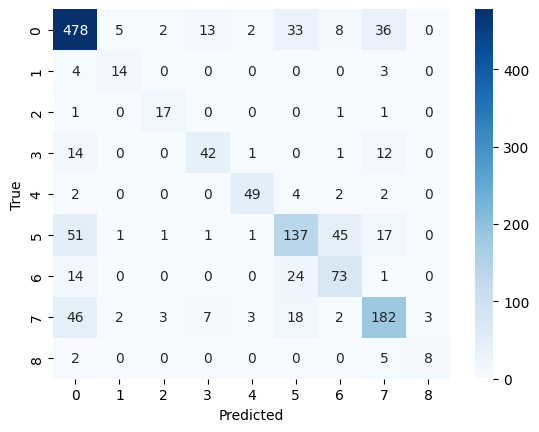

In [ ]:
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

model.eval()
all_preds = []
all_probs = []
all_y = []

with torch.no_grad():
    for x, y in tqdm(test_loader):
        x, y = x.to(device), y.to(device).long()
        out = model(x)

        probs = torch.softmax(out, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_probs.append(probs.cpu())
        all_preds.append(preds.cpu())
        all_y.append(y.cpu())


all_probs = torch.cat(all_probs).numpy()
all_preds_top3 = np.argsort(all_probs, axis=1)[:,-3:]
all_preds = torch.cat(all_preds).numpy().ravel()
all_y = torch.cat(all_y).numpy().ravel()

test_acc = accuracy_score(all_y, all_preds)
test_f1_mic = f1_score(all_y, all_preds, average="micro")
test_f1_mac = f1_score(all_y, all_preds, average="macro")
conf_mat = confusion_matrix(all_y, all_preds)

for i in range(9):
    acc = (all_preds[all_y == i] == i).sum() / (all_y == i).sum()
    print(f"accuracy on class {i}: {acc:.4f}")

print()
print(f"  Test accuracy: {test_acc:.4f}")
print(f"  Test f1 micro: {test_f1_mic:.4f}")
print(f"  Test f1 macro: {test_f1_mac:.4f}")

sns.heatmap(conf_mat, cmap="Blues", annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

#### При большой уверенности

In [ ]:
wh = np.where((all_probs > 0.95))
pred = wh[1]
y = all_y[wh[0]]
accuracy_score(y, pred)

0.8644918444165621

In [ ]:
len(y) / len(all_y)

0.5717360114777619

In [ ]:
np.unique(y, return_counts=True)[1] / np.unique(all_y, return_counts=True)[1]

array([0.70190641, 0.42857143, 0.8       , 0.57142857, 0.59322034,
       0.32283465, 0.45535714, 0.56390977, 0.6       ])

In [ ]:
y_prednonzero = y[np.where(pred != 0)]
pred_prednonzero = pred[np.where(pred != 0)]
accuracy_score(y_prednonzero, pred_prednonzero)

0.8227513227513228

In [ ]:
len(y_prednonzero) / len(all_y)

0.27116212338593976

In [ ]:
np.unique(y_prednonzero, return_counts=True)[1] / np.unique(all_y, return_counts=True)[1]

array([0.04679376, 0.33333333, 0.8       , 0.5       , 0.59322034,
       0.27165354, 0.41964286, 0.5037594 , 0.53333333])

#### Всякое

In [ ]:
(conf_mat[0][0] + conf_mat[1:,1:].sum()) / conf_mat.sum().sum()

0.832855093256815

In [ ]:
conf_mat[:, 1:]

array([[  5,   2,  13,   2,  33,   8,  36,   0],
       [ 14,   0,   0,   0,   0,   0,   3,   0],
       [  0,  17,   0,   0,   0,   1,   1,   0],
       [  0,   0,  42,   1,   0,   1,  12,   0],
       [  0,   0,   0,  49,   4,   2,   2,   0],
       [  1,   1,   1,   1, 137,  45,  17,   0],
       [  0,   0,   0,   0,  24,  73,   1,   0],
       [  2,   3,   7,   3,  18,   2, 182,   3],
       [  0,   0,   0,   0,   0,   0,   5,   8]], dtype=int64)

In [ ]:
conf_mat[:, 0].sum() / conf_mat.sum().sum()

0.43902439024390244

In [ ]:
conf_mat[0, 1:].sum() / conf_mat[:, 1:].sum()

0.1265984654731458

In [ ]:
conf_mat[0, 1:].sum() / conf_mat[:, 1:].sum()

#### За вычетом конфьюжна пересекающихся классов

In [ ]:
k = 0
for pred, true in zip(all_preds, all_y):
    if pred in [5,6] and true in [5,6]:
        k += 1
        continue
    if pred in [5,7] and true in [5,7]:
        k += 1
        continue
    if pred == true:
        k += 1
acc = k / all_y.shape[0]
print(f"light accuracy: {acc:.4f}")

light accuracy: 0.7920


In [ ]:
mat = conf_mat.copy()
wh = np.where(all_probs > 0.999)
preds = wh[1]
y = all_y[wh[0]]
k = 0
for pred, true in zip(preds, y):
    if pred in [5,6] and true in [5,6]:
        k += 1
        continue
    if pred in [5,7] and true in [5,7]:
        k += 1
        continue
    if pred == true:
        k += 1
acc = k / y.shape[0]
acc

0.9545454545454546

In [ ]:
len(y) / len(all_y)

0.23672883787661406

In [ ]:
for i in range(9):
    if conf_mat[i].sum() + conf_mat[:,i].sum() > 1. * (3 * conf_mat[i][i]):
        print(f"{i}: {conf_mat[i].sum() + conf_mat[:,i].sum() - 2 * conf_mat[i][i]} wrong, {conf_mat[i][i]} right")

1: 11 wrong, 6 right
3: 62 wrong, 36 right
6: 100 wrong, 53 right


In [ ]:
np.mean([0.8182, 0.6000, 0.8889, 0.4328, 0.2500, 0.5882, 0.6866, 0.1429, 0.2727, 0.7850,  0.4038,  0.5316,  0.3835,  0.5000])

0.5203000000000001

Наличие подтоплений',
        'Наличие сухостойных деревьев (только деревья)',
        'Нарушение содержания мест проведения работ по комплексному благоустройству',
        'Нарушение содержания мест проведения работ по ремонту инженерных сооружений',
        'Нарушение содержания объектов ЦОДД',
        'Нарушение содержания объектов гор.моста',
        'Нарушение содержания рекламных конструкций',
        'Нарушение содержания строительной площадки',
        'Нарушение содержания фасадов нежилых зданий и сооружений',
        'Нарушение состояния фасада жилых зданий',
        'Нарушения в содержание дорог, МАФов, остановочных павильонов, опор УНО, опор мосгортранс',
        'Нарушения по санитарии, освещению, ТПУ, полосе отвода ж\\д',
        'Неудовлетворительное содержание ОЛХ

In [ ]:
probs_argsorted = np.argsort(all_probs, axis=1)
print(f"total objects:  {all_probs.shape[0]}")
for i in range(1, 6):
    k = 0

    mask = ((probs_argsorted[:,-i:]) == all_y[:, None]).any(axis=1)

    for j in probs_argsorted[:,-i:]:
        if 8 in j: k += 1

    print(f"top {i} accuracy:   {np.where(mask)[0].shape[0] / all_probs.shape[0]}")

    print(k)

total objects:  1394
top 1 accuracy:   0.7173601147776184
11
top 2 accuracy:   0.9110473457675753
36
top 3 accuracy:   0.9705882352941176
67
top 4 accuracy:   0.9899569583931134
103
top 5 accuracy:   0.9971305595408895
171


In [ ]:
data = pd.read_csv("data/attr_classifier.csv")

In [ ]:
facade = Facade(transform=Resize((384, 384)), root_dir=root_dir, img_dir=img_dir, csv_path=csv_path, attr="Нарушение содержания объектов ЦОДД")

Dataset loaded: 1359 images


In [ ]:
k = 0
d = train_ds
for ind in range(len(ds)):
    if ind not in d.indices:
        continue
    if data.iloc[ds.orig_indices[ind]].attr_val == 0:
        k += 1
        #print(ind)
        #plt.imshow(facade[ind][0])
        #plt.show()

print()
print(len(d))
print(k)
print(k / len(d))


6082
889
0.14616902334758303


In [ ]:
def predict_image(model, image_path, transform, device):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image = transform(image)

    image = image.unsqueeze(0)
    image = image.to(device)

    with torch.no_grad():
        out = model(image)
        probs = torch.softmax(out, dim=1)
        preds = torch.argmax(probs, dim=1)

    return {
        "probability": probs.cpu().numpy(),
        "prediction": preds.cpu().numpy()
    }

In [ ]:
image_path = "data/test/photo_2026-03-06_16-35-59.jpg"
predict_image(model, image_path, default_transform, device)

{'probability': array([[7.4036745e-03, 3.8704748e-06, 5.6453903e-10, 2.1271831e-08,
         2.6514368e-07, 5.4857177e-01, 4.4402036e-01, 2.9994947e-08,
         4.9325422e-10]], dtype=float32),
 'prediction': array([5], dtype=int64)}

In [ ]:
d = test_ds
imgs = []
for ind in range(len(ds)):
    if ind not in d.indices:
        continue
    if data.iloc[ds.orig_indices[ind]].attr_val == 0:
        imgs.append((data.iloc[ds.orig_indices[ind]].ID, data.iloc[ds.orig_indices[ind]].img_num))

In [ ]:
preds = np.zeros(len(imgs))
for ind, i in enumerate(imgs):
    preds[ind] = predict_image(model, os.path.join(root_dir, img_dir, str(i[0]) + "_" + str(i[1]) + ".jpg"), default_transform, device, threshold=0.9)["probability"]
preds.mean()

NameError: name 'imgs' is not defined

In [ ]:
model = models.convnext_small()
model.classifier[2] = nn.Linear(model.classifier[2].in_features, 9, bias=True)
model.load_state_dict(torch.load("models/atomic_classifier/good_classes_convnext_s_2.pth", weights_only=True))
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device);

#### Сохранение

#### convnext_s_2.pth - 0.91 top 5

In [ ]:
torch.save(model.state_dict(), "models/atomic_classifier/good_classes_convnext_s_3.pth")

In [ ]:
with open("fixed_test_sets/resident_facade.txt", "x") as f:
    for i in test_ds.indices:
        f.write(str(i) + "\n")

### Папки:
not_resident_facade

resident_facade

roads_bus_stops

sanitation_lighting

codd

## Классы

! дисбаланс по меткам указан как 0/1

---

### Нарушения в содержание дорог, МАФов, остановочных павильонов, опор УНО, опор мосгортранс
3763 объектов, дисбаланс 0.28/0.72

thresh = 0.7

accuracy: 0.8613

balanced accuracy: 0.8413

auc: 0.8969

---

### Нарушение содержания фасадов нежилых зданий и сооружений:
6990 объектов, дисбаланс 0.17/0.83

thresh = 0.8

accuracy: 0.8195

balanced accuracy: 0.7729

auc: 0.8699

---

### Нарушение содержания объектов гор.мост
1527 объектов, дисбаланс 0.64/0.36


---
### Нарушения по санитарии, освещению, ТПУ, полосе отвода ж\д:
3132 объектов, дисбаланс 0.33/0.67

thresh = 0.9

accuracy: acc = 0.83

balanced accuracy: 0.83

auc: 0.8699

---
### Нарушение содержания строительной площадки
641 объектов, дисбаланс 0.10/0.90


---
### Нарушение содержания мест проведения работ по комплексному благоустройству
859 объектов, дисбаланс 0.04/0.96


---
### Нарушение содержания мест проведения работ по ремонту инженерных сооружений
1382 объектов, дисбаланс 0.76/0.24


----
### Наличие подтоплений
1166 объектов, дисбаланс 0.83/0.17


---
### Нарушение содержания объектов ЦОДД

1707 объектов, дисбаланс 0.43/0.57

thresh = 0.65

accuracy: 0.7721

balanced accuracy: 0.7713

auc: 0.8574

---
### Нарушение содержания рекламных конструкций
1073 объектов, дисбаланс 0.91/0.09


---
### Нарушение состояния фасада жилых зданий
2068 объектов, дисбаланс 0.46/0.54

thresh = 0.4

accuracy: 0.9030

balanced accuracy: 0.8864

auc: 0.9522


---
### Наличие сухостойных деревьев (только деревья)
262 объектов, дисбаланс 0.00/1.00 (мда)


---
### Неудовлетворительное содержание ОЛХ
177 объектов (отлично), дисбаланс 0.07/0.93

In [ ]:
for i in data.attr.unique():
    count = len(data[data["attr"] == i])
    mean = data[data["attr"] == i]["attr_val"].mean()
    print(f"{i}:    {count}    {mean:.2f}")

Нарушения в содержание дорог, МАФов, остановочных павильонов, опор УНО, опор мосгортранс:    3763    0.72
Нарушение содержания фасадов нежилых зданий и сооружений:    6990    0.83
Нарушение содержания объектов гор.моста:    1527    0.36
Нарушения по санитарии, освещению, ТПУ, полосе отвода ж\д:    3132    0.67
Нарушение содержания строительной площадки:    641    0.90
Нарушение содержания мест проведения работ по комплексному благоустройству:    859    0.96
Нарушение содержания мест проведения работ по ремонту инженерных сооружений:    1382    0.24
Наличие подтоплений:    1166    0.17
Нарушение содержания объектов ЦОДД:    1707    0.43
Нарушение содержания рекламных конструкций:    1073    0.09
Нарушение состояния фасада жилых зданий:    2068    0.54
Наличие сухостойных деревьев (только деревья):    262    1.00
Неудовлетворительное содержание ОЛХ:    177    0.93


In [ ]:
data = pd.read_csv("data/atomic_no_noise.csv")

In [ ]:
data[data['ID'] == 177107535]

,Unnamed: 0,img,attr,ID,img_num,Комментарий,Гостевая ссылка на проверку,attr_ind
20,20,https://ckkb-mos.online/storage/uploads/images/10645/91902/4108678/EWMksrjnZx4L.jpg,-,177107535,0,NaN,https://ckkb-mos.online/link/9KC4aZ3oxbyJSlUhJzysNBW8XB5JB33f,0.0


In [ ]:
data.loc[data["attr_val"] == 0, "attr"] = "-"

In [ ]:
data["attr"].value_counts()

attr
-                                                                                           5935
Нарушение содержания фасадов нежилых зданий и сооружений                                    5769
Нарушения в содержание дорог, МАФов, остановочных павильонов, опор УНО, опор мосгортранс    2695
Нарушения по санитарии, освещению, ТПУ, полосе отвода ж\д                                   2105
Нарушение состояния фасада жилых зданий                                                     1120
Нарушение содержания мест проведения работ по комплексному благоустройству                   825
Нарушение содержания объектов ЦОДД                                                           731
Нарушение содержания строительной площадки                                                   574
Нарушение содержания объектов гор.моста                                                      552
Нарушение содержания мест проведения работ по ремонту инженерных сооружений                  322
Наличие сухостойных дерев

In [ ]:
data = data[~data['attr_ind'].isin(bad_idx)]

In [ ]:
oe = OrdinalEncoder().fit(ds[["x"]])

In [ ]:
oe.transform(ds[["x"]])

array([[0.],
       [1.],
       [2.],
       [0.],
       [2.]])

In [ ]:
ds = pd.DataFrame(np.array(["A", "B", "C", "A", "C"]), columns=["x"])

In [ ]:
ds

,x
0,A
1,B
2,C
3,A
4,C


In [ ]:
attr_oe = OrdinalEncoder().fit(data[["attr"]])

In [ ]:
data.drop(["attr_ind"], axis=1, inplace=True)

In [ ]:
data[["attr_ind"]] = attr_oe.transform(data[["attr"]])

In [ ]:
data

,Unnamed: 0,img,attr,ID,img_num,Комментарий,Гостевая ссылка на проверку,attr_ind
0,0,https://ckkb-mos.online/storage/uploads/images/10645/92192/4108578/1xT4OxIM1Yuq.jpg,"Нарушения в содержание дорог, МАФов, остановочных павильонов, опор УНО, опор мосгортранс",177104874,0,Череповетская ул. д.14,https://ckkb-mos.online/link/TloUtGBhN6jJdW5SZiWY35RaMl1CFPTt,7.0
1,1,https://ckkb-mos.online/storage/uploads/images/10645/92192/4108578/KQlpdUvDLxef.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,177104876,0,", череповетская д.14 а",https://ckkb-mos.online/link/TloUtGBhN6jJdW5SZiWY35RaMl1CFPTt,5.0
2,2,https://ckkb-mos.online/storage/uploads/images/10645/92192/4108578/YpP2fpXi5rRh.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,177104876,1,", череповетская д.14 а",https://ckkb-mos.online/link/TloUtGBhN6jJdW5SZiWY35RaMl1CFPTt,5.0
3,3,https://ckkb-mos.online/storage/uploads/images/10645/92192/4108578/zPBW2zALQyfq.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,177104876,2,", череповетская д.14 а",https://ckkb-mos.online/link/TloUtGBhN6jJdW5SZiWY35RaMl1CFPTt,5.0
4,4,https://ckkb-mos.online/storage/uploads/images/10645/92727/4108588/8AKFil1qd3J1.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,177104996,0,"Д.18, школа д.12",https://ckkb-mos.online/link/s03oi5QVVPE0trTkghjJEYNUYAntJHwu,5.0
...,...,...,...,...,...,...,...,...
21350,24742,https://ckkb-mos.online/storage/uploads/images/10645/147575/5458016/Wm7XbGtAoGFz.jpg,Неудовлетворительное содержание ОЛХ,233603599,4,NaN,https://ckkb-mos.online/link/BDNsrWbe6nmfRGDkK68fqDkabAxIeJmW,8.0
21351,24743,https://ckkb-mos.online/storage/uploads/images/10645/147575/5458016/DZfvZE4vhX12.jpg,Неудовлетворительное содержание ОЛХ,233603599,5,NaN,https://ckkb-mos.online/link/BDNsrWbe6nmfRGDkK68fqDkabAxIeJmW,8.0
21352,24744,https://ckkb-mos.online/storage/uploads/images/10645/147575/5458016/XSFn5AhMo3aA.jpg,Неудовлетворительное содержание ОЛХ,233603599,6,NaN,https://ckkb-mos.online/link/BDNsrWbe6nmfRGDkK68fqDkabAxIeJmW,8.0
21353,24745,https://ckkb-mos.online/storage/uploads/images/10645/147575/5458016/q5FlWpp0dDyT.jpg,Неудовлетворительное содержание ОЛХ,233603599,7,NaN,https://ckkb-mos.online/link/BDNsrWbe6nmfRGDkK68fqDkabAxIeJmW,8.0


In [ ]:
data.drop(["attr_val"], axis=1, inplace=True)

In [ ]:
data[["attr_ind"]] = attr_oe.transform(data[["attr"]])

In [ ]:
data.to_csv("data/good_atomic_no_noise.csv", index=False)

In [ ]:
data = pd.read_csv("data/atomic_classifier.csv")

In [ ]:
len(train_ds.indices)

19219

In [ ]:
len(np.unique(train_ds.indices))

19219

In [ ]:
zalupa = orig_ind.copy()

In [ ]:
len(np.unique(np.r_[zalupa, orig_ind]))

21355

In [ ]:
data.iloc[[0, 1, 2, 4, 5]]

,img,attr,ID,img_num,Комментарий,Гостевая ссылка на проверку,attr_ind
0,https://ckkb-mos.online/storage/uploads/images/10645/92192/4108578/1xT4OxIM1Yuq.jpg,"Нарушения в содержание дорог, МАФов, остановочных павильонов, опор УНО, опор мосгортранс",177104874,0,Череповетская ул. д.14,https://ckkb-mos.online/link/TloUtGBhN6jJdW5SZiWY35RaMl1CFPTt,11.0
1,https://ckkb-mos.online/storage/uploads/images/10645/92192/4108578/KQlpdUvDLxef.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,177104876,0,", череповетская д.14 а",https://ckkb-mos.online/link/TloUtGBhN6jJdW5SZiWY35RaMl1CFPTt,9.0
2,https://ckkb-mos.online/storage/uploads/images/10645/92192/4108578/YpP2fpXi5rRh.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,177104876,1,", череповетская д.14 а",https://ckkb-mos.online/link/TloUtGBhN6jJdW5SZiWY35RaMl1CFPTt,9.0
4,https://ckkb-mos.online/storage/uploads/images/10645/92727/4108588/8AKFil1qd3J1.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,177104996,0,"Д.18, школа д.12",https://ckkb-mos.online/link/s03oi5QVVPE0trTkghjJEYNUYAntJHwu,9.0
5,https://ckkb-mos.online/storage/uploads/images/10645/92727/4108588/r1dIvGBjMQDv.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,177104996,1,"Д.18, школа д.12",https://ckkb-mos.online/link/s03oi5QVVPE0trTkghjJEYNUYAntJHwu,9.0


In [ ]:
orig_ind = []
for i in train_ds.indices:
    orig_ind.append(ds.orig_indices[i])
data.iloc[orig_ind]["attr_ind"].value_counts().sort_index()

attr_ind
0.0     5341
1.0      182
2.0      244
3.0      758
4.0      290
5.0      663
6.0      485
7.0       91
8.0      508
9.0     5169
10.0    1016
11.0    2426
12.0    1899
13.0     147
Name: count, dtype: int64

In [ ]:
np.unique(ds.labels, return_counts=True)

(array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13.]),
 array([5935,  202,  262,  825,  322,  731,  552,   98,  574, 5769, 1120,
        2695, 2105,  165], dtype=int64))

In [ ]:
len(orig_ind)

2136

In [ ]:
data["attr_ind"].value_counts()

attr_ind
0.0     9281
9.0     5785
11.0    2711
12.0    2109
10.0    1120
3.0      825
5.0      735
8.0      574
6.0      552
4.0      327
2.0      262
1.0      202
13.0     165
7.0       99
Name: count, dtype: int64

In [ ]:
orig_ind[0]

8102

In [ ]:
attr_oe.categories_

[array(['Наличие подтоплений',
        'Наличие сухостойных деревьев (только деревья)',
        'Нарушение содержания мест проведения работ по комплексному благоустройству',
        'Нарушение содержания мест проведения работ по ремонту инженерных сооружений',
        'Нарушение содержания объектов ЦОДД',
        'Нарушение содержания объектов гор.моста',
        'Нарушение содержания рекламных конструкций',
        'Нарушение содержания строительной площадки',
        'Нарушение содержания фасадов нежилых зданий и сооружений',
        'Нарушение состояния фасада жилых зданий',
        'Нарушения в содержание дорог, МАФов, остановочных павильонов, опор УНО, опор мосгортранс',
        'Нарушения по санитарии, освещению, ТПУ, полосе отвода ж\\д',
        'Неудовлетворительное содержание ОЛХ'], dtype=object)]

In [ ]:
attr_oe.categories_

[array(['-', 'Наличие подтоплений',
        'Наличие сухостойных деревьев (только деревья)',
        'Нарушение содержания объектов ЦОДД',
        'Нарушение содержания объектов гор.моста',
        'Нарушение содержания фасадов нежилых зданий и сооружений',
        'Нарушение состояния фасада жилых зданий',
        'Нарушения в содержание дорог, МАФов, остановочных павильонов, опор УНО, опор мосгортранс',
        'Неудовлетворительное содержание ОЛХ'], dtype=object)]

In [ ]:
data = pd.read_csv(os.path.join(root_dir, csv_path))

In [ ]:
data[data["attr_ind"] == 5]

,Unnamed: 0,img,attr,ID,img_num,Комментарий,Гостевая ссылка на проверку,attr_ind
1,1,https://ckkb-mos.online/storage/uploads/images/10645/92192/4108578/KQlpdUvDLxef.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,177104876,0,", череповетская д.14 а",https://ckkb-mos.online/link/TloUtGBhN6jJdW5SZiWY35RaMl1CFPTt,5.0
2,2,https://ckkb-mos.online/storage/uploads/images/10645/92192/4108578/YpP2fpXi5rRh.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,177104876,1,", череповетская д.14 а",https://ckkb-mos.online/link/TloUtGBhN6jJdW5SZiWY35RaMl1CFPTt,5.0
3,3,https://ckkb-mos.online/storage/uploads/images/10645/92192/4108578/zPBW2zALQyfq.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,177104876,2,", череповетская д.14 а",https://ckkb-mos.online/link/TloUtGBhN6jJdW5SZiWY35RaMl1CFPTt,5.0
4,4,https://ckkb-mos.online/storage/uploads/images/10645/92727/4108588/8AKFil1qd3J1.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,177104996,0,"Д.18, школа д.12",https://ckkb-mos.online/link/s03oi5QVVPE0trTkghjJEYNUYAntJHwu,5.0
5,5,https://ckkb-mos.online/storage/uploads/images/10645/92727/4108588/r1dIvGBjMQDv.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,177104996,1,"Д.18, школа д.12",https://ckkb-mos.online/link/s03oi5QVVPE0trTkghjJEYNUYAntJHwu,5.0
...,...,...,...,...,...,...,...,...
17375,24668,https://ckkb-mos.online/storage/uploads/images/10645/147576/5456245/lrSyTSxxKglp.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,233547802,7,NaN,https://ckkb-mos.online/link/f6tpGRLSvnCNVTaKWpyswgSRpqGcx6LG,5.0
17408,24711,https://ckkb-mos.online/storage/uploads/images/10645/147575/5458016/yW2g0Ag24IqS.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,233603582,0,NaN,https://ckkb-mos.online/link/BDNsrWbe6nmfRGDkK68fqDkabAxIeJmW,5.0
17409,24712,https://ckkb-mos.online/storage/uploads/images/10645/147575/5458016/Uv6JdS7tIuMZ.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,233603582,1,NaN,https://ckkb-mos.online/link/BDNsrWbe6nmfRGDkK68fqDkabAxIeJmW,5.0
17410,24713,https://ckkb-mos.online/storage/uploads/images/10645/147575/5458016/pS33gw9aAci5.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,233603582,2,NaN,https://ckkb-mos.online/link/BDNsrWbe6nmfRGDkK68fqDkabAxIeJmW,5.0


In [ ]:
data.set_index(data['Unnamed: 0'], inplace=True)

In [ ]:
data.drop(["Unnamed: 0"], axis=1, inplace=True)

In [ ]:
data

,img,attr,ID,img_num,Комментарий,Гостевая ссылка на проверку,attr_ind
Unnamed: 0,,,,,,,
0,https://ckkb-mos.online/storage/uploads/images/10645/92192/4108578/1xT4OxIM1Yuq.jpg,"Нарушения в содержание дорог, МАФов, остановочных павильонов, опор УНО, опор мосгортранс",177104874,0,Череповетская ул. д.14,https://ckkb-mos.online/link/TloUtGBhN6jJdW5SZiWY35RaMl1CFPTt,7.0
1,https://ckkb-mos.online/storage/uploads/images/10645/92192/4108578/KQlpdUvDLxef.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,177104876,0,", череповетская д.14 а",https://ckkb-mos.online/link/TloUtGBhN6jJdW5SZiWY35RaMl1CFPTt,5.0
2,https://ckkb-mos.online/storage/uploads/images/10645/92192/4108578/YpP2fpXi5rRh.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,177104876,1,", череповетская д.14 а",https://ckkb-mos.online/link/TloUtGBhN6jJdW5SZiWY35RaMl1CFPTt,5.0
3,https://ckkb-mos.online/storage/uploads/images/10645/92192/4108578/zPBW2zALQyfq.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,177104876,2,", череповетская д.14 а",https://ckkb-mos.online/link/TloUtGBhN6jJdW5SZiWY35RaMl1CFPTt,5.0
4,https://ckkb-mos.online/storage/uploads/images/10645/92727/4108588/8AKFil1qd3J1.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,177104996,0,"Д.18, школа д.12",https://ckkb-mos.online/link/s03oi5QVVPE0trTkghjJEYNUYAntJHwu,5.0
...,...,...,...,...,...,...,...
24742,https://ckkb-mos.online/storage/uploads/images/10645/147575/5458016/Wm7XbGtAoGFz.jpg,Неудовлетворительное содержание ОЛХ,233603599,4,NaN,https://ckkb-mos.online/link/BDNsrWbe6nmfRGDkK68fqDkabAxIeJmW,8.0
24743,https://ckkb-mos.online/storage/uploads/images/10645/147575/5458016/DZfvZE4vhX12.jpg,Неудовлетворительное содержание ОЛХ,233603599,5,NaN,https://ckkb-mos.online/link/BDNsrWbe6nmfRGDkK68fqDkabAxIeJmW,8.0
24744,https://ckkb-mos.online/storage/uploads/images/10645/147575/5458016/XSFn5AhMo3aA.jpg,Неудовлетворительное содержание ОЛХ,233603599,6,NaN,https://ckkb-mos.online/link/BDNsrWbe6nmfRGDkK68fqDkabAxIeJmW,8.0


In [ ]:
data[data["attr_ind"] == 5].index

Index([    1,     2,     3,     4,     5,     6,     7,     9,    18,    21,
       ...
       24663, 24664, 24665, 24666, 24667, 24668, 24711, 24712, 24713, 24714],
      dtype='int64', name='Unnamed: 0', length=5769)

In [ ]:
d.to_csv("data/good_atomic_no_noise_less_noresident.csv", index=False)

In [ ]:
ind = np.random.choice(data[data["attr_ind"] == 5].index, size=3500, replace=False)

In [ ]:
k = 0
for i in data.index:
    if not i in ind:
        k += 1
k

14795

In [ ]:
ind = np.random.choice(data[data["attr_ind"] == 5].index, size=3500, replace=False)
d = data[~data.index.isin(ind)]

In [ ]:
data[data.index.isin(data[data["attr_ind"] == 5].index[np.random.choice(data[data["attr_ind"] == 5].index, size=3500)])]

IndexError: index 15322 is out of bounds for axis 0 with size 5769

In [ ]:
data.index

Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,     9,
       ...
       24737, 24738, 24739, 24740, 24741, 24742, 24743, 24744, 24745, 24746],
      dtype='int64', name='Unnamed: 0', length=17431)

In [ ]:
d.sum()

2455